In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../../../testing/object_lc_1gib_sizes.csv")
df

,Norder,Npix,num_rows,uncompressed_bytes,uncompressed_mib,compressed_bytes,compressed_mib,file_bytes,file_mib,path
0,2,107,7592,7429895,7.09,6163048,5.88,6530369,6.23,Norder=2/Dir=0/Npix=107.parquet
1,4,1098,5365,5190417,4.95,4410981,4.21,4778435,4.56,Norder=4/Dir=0/Npix=1098.parquet
2,4,1193,3323,5148498,4.91,4423395,4.22,4791451,4.57,Norder=4/Dir=0/Npix=1193.parquet
3,4,1205,15922,15814556,15.08,13147402,12.54,13523573,12.90,Norder=4/Dir=0/Npix=1205.parquet
4,4,1606,22620,24084373,22.97,19733535,18.82,20106529,19.18,Norder=4/Dir=0/Npix=1606.parquet
...,...,...,...,...,...,...,...,...,...,...
54131,8,785987,9878,32354348,30.86,27472738,26.20,28135796,26.83,Norder=8/Dir=780000/Npix=785987.parquet
54132,8,785992,10054,31632038,30.17,26999258,25.75,27654452,26.37,Norder=8/Dir=780000/Npix=785992.parquet
54133,8,785993,8362,26481607,25.25,22712783,21.66,23367165,22.28,Norder=8/Dir=780000/Npix=785993.parquet
54134,8,785994,10117,31049110,29.61,26588872,25.36,27243942,25.98,Norder=8/Dir=780000/Npix=785994.parquet


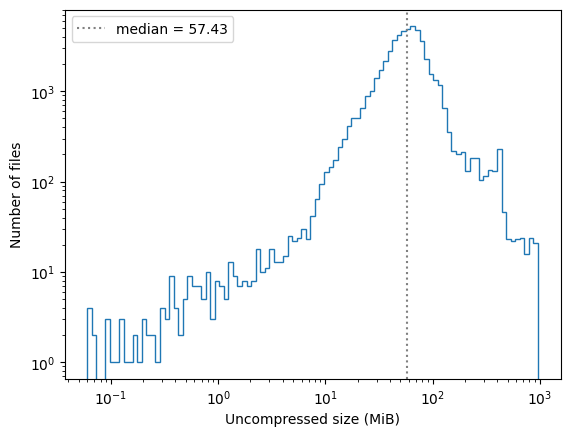

In [2]:
def plot_size_hist(series, xlabel, n_bins=100):
    bins = np.logspace(np.log10(series.min()), np.log10(series.max()), n_bins)
    plt.hist(series, bins=bins, histtype="step")
    median = series.median()
    plt.axvline(median, linestyle=":", color="gray", label=f"median = {median:.2f}")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("Number of files")
    plt.legend()


plot_size_hist(df["uncompressed_mib"], "Uncompressed size (MiB)")

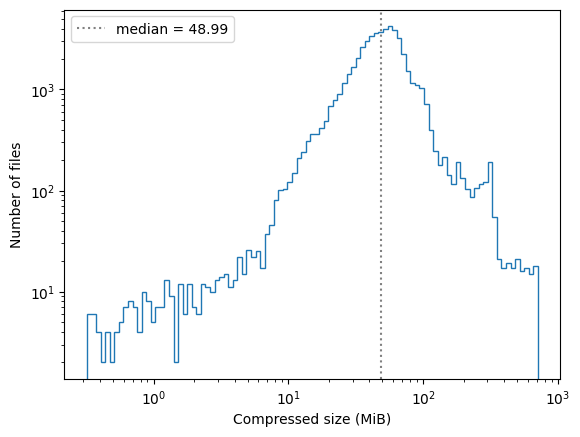

In [3]:
plot_size_hist(df["file_mib"], "Compressed size (MiB)")

/Users/smcmu/code/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

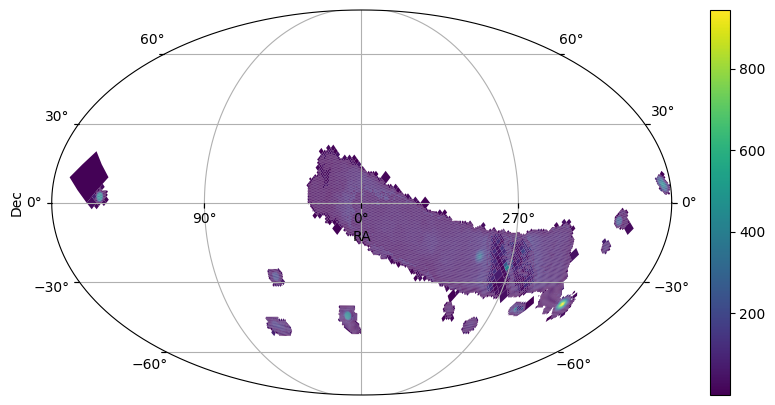

In [4]:
from hats.inspection.visualize_catalog import plot_healpix_map

plot_healpix_map(df["uncompressed_mib"].to_numpy(), ipix=df["Npix"].to_numpy(), depth=df["Norder"].to_numpy())

/Users/smcmu/code/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

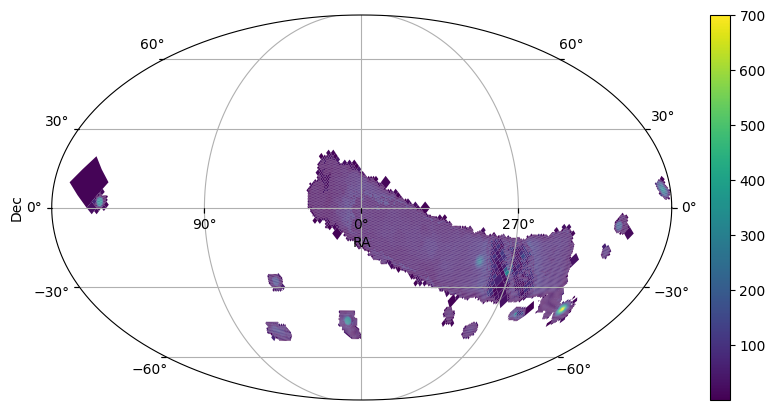

In [5]:
plot_healpix_map(df["file_mib"].to_numpy(), ipix=df["Npix"].to_numpy(), depth=df["Norder"].to_numpy())

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

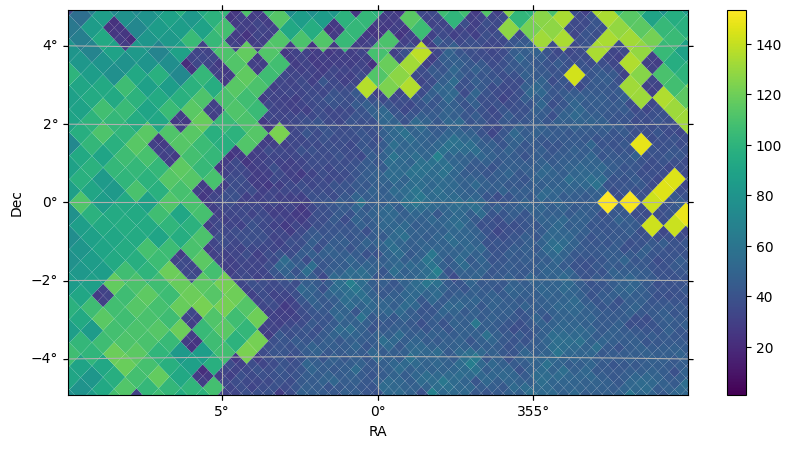

In [6]:
from astropy.coordinates import SkyCoord
import astropy.units as u

plot_healpix_map(
    df["uncompressed_mib"].to_numpy(),
    ipix=df["Npix"].to_numpy(),
    depth=df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=10 * u.deg,
    projection="TAN",
)

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

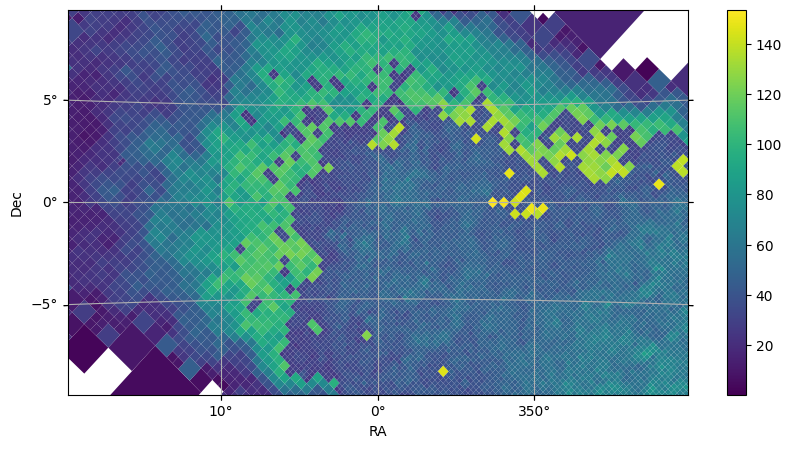

In [17]:
plot_healpix_map(
    df["uncompressed_mib"].to_numpy(),
    ipix=df["Npix"].to_numpy(),
    depth=df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=20 * u.deg,
    projection="TAN",
)

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

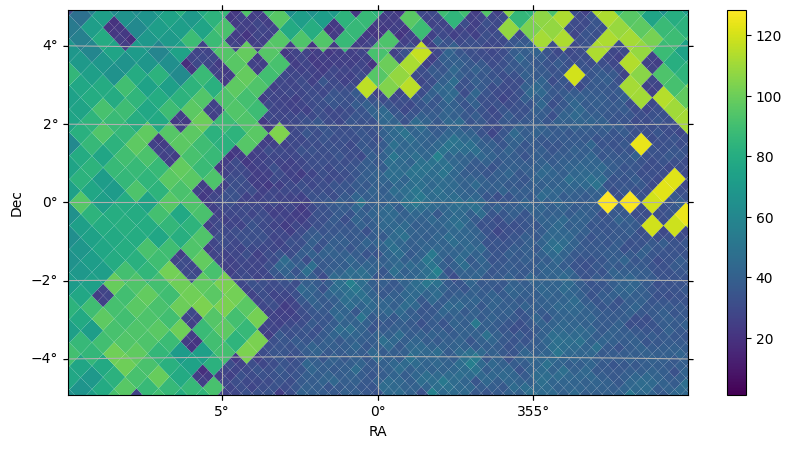

In [7]:
plot_healpix_map(
    df["file_mib"].to_numpy(),
    ipix=df["Npix"].to_numpy(),
    depth=df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=10 * u.deg,
    projection="TAN",
)

In [8]:
rows_df = pd.read_csv("../../../../testing/object_lc_rows_sizes.csv")
rows_df

,Norder,Npix,num_rows,uncompressed_bytes,uncompressed_mib,compressed_bytes,compressed_mib,file_bytes,file_mib,path
0,2,107,7592,7429895,7.09,6163048,5.88,6530369,6.23,Norder=2/Dir=0/Npix=107.parquet
1,4,1098,5365,5190417,4.95,4410981,4.21,4778435,4.56,Norder=4/Dir=0/Npix=1098.parquet
...,...,...,...,...,...,...,...,...,...,...
108823,9,3142911,4448,13532801,12.91,11489465,10.96,12141797,11.58,Norder=9/Dir=3140000/Npix=3142911.parquet
108824,9,3144224,124,181331,0.17,189366,0.18,443009,0.42,Norder=9/Dir=3140000/Npix=3144224.parquet


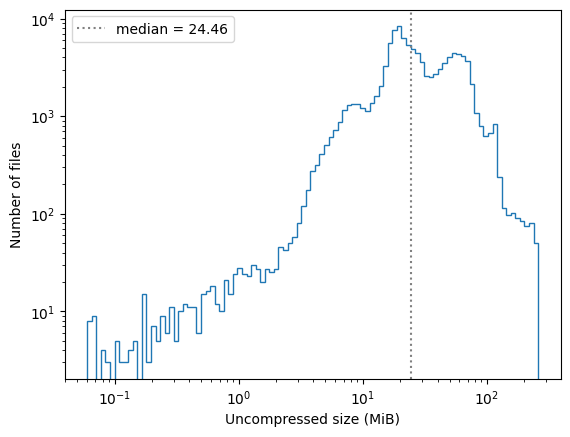

In [9]:
plot_size_hist(rows_df["uncompressed_mib"], "Uncompressed size (MiB)")

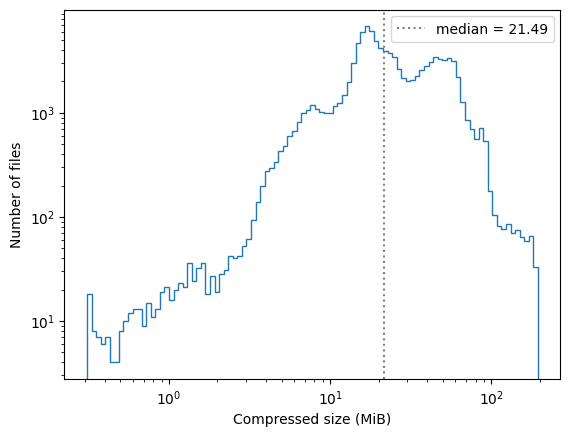

In [10]:
plot_size_hist(rows_df["file_mib"], "Compressed size (MiB)")

/Users/smcmu/code/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

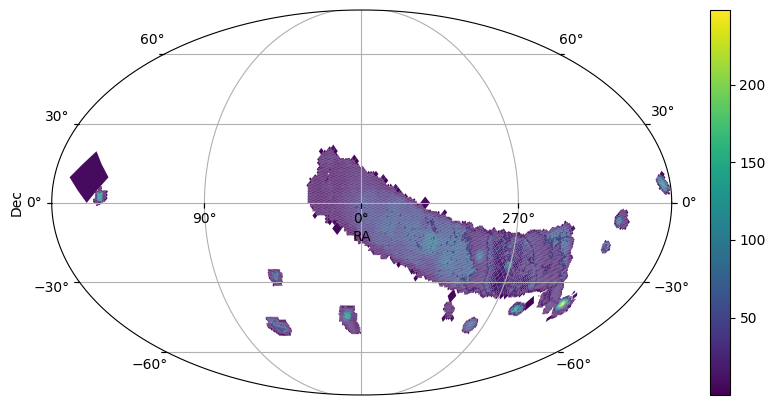

In [11]:
plot_healpix_map(rows_df["uncompressed_mib"].to_numpy(), ipix=rows_df["Npix"].to_numpy(), depth=rows_df["Norder"].to_numpy())

/Users/smcmu/code/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

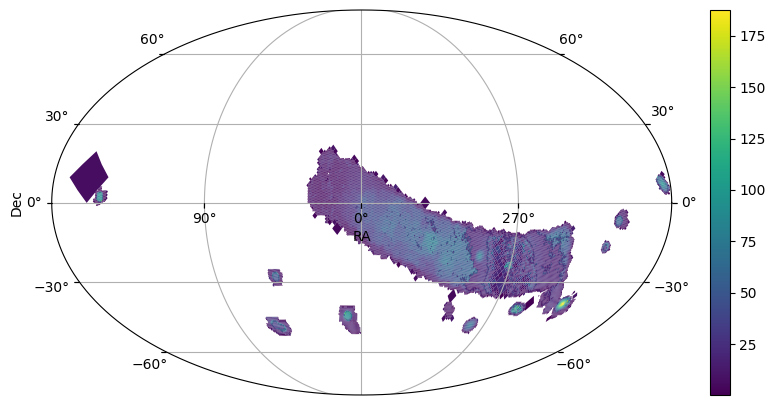

In [12]:
plot_healpix_map(rows_df["file_mib"].to_numpy(), ipix=rows_df["Npix"].to_numpy(), depth=rows_df["Norder"].to_numpy())

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

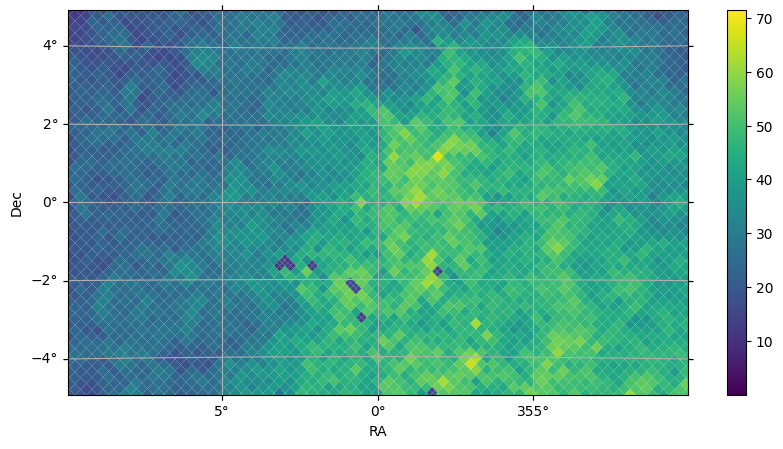

In [13]:
plot_healpix_map(
    rows_df["uncompressed_mib"].to_numpy(),
    ipix=rows_df["Npix"].to_numpy(),
    depth=rows_df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=10 * u.deg,
    projection="TAN",
)

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

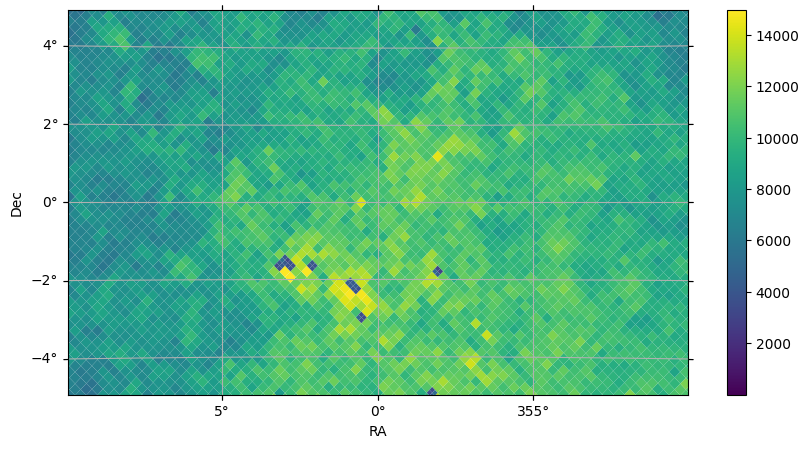

In [14]:
plot_healpix_map(
    rows_df["num_rows"].to_numpy(),
    ipix=rows_df["Npix"].to_numpy(),
    depth=rows_df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=10 * u.deg,
    projection="TAN",)

(<Figure size 1000x500 with 2 Axes>, <WCSAxes: >)

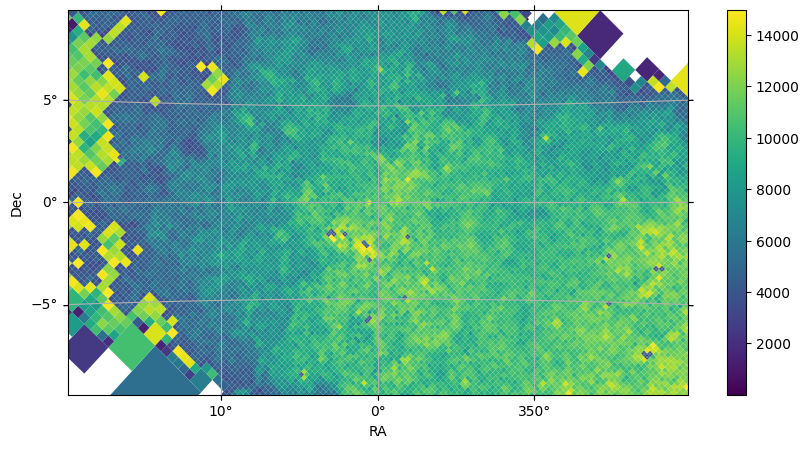

In [15]:
plot_healpix_map(
    rows_df["num_rows"].to_numpy(),
    ipix=rows_df["Npix"].to_numpy(),
    depth=rows_df["Norder"].to_numpy(),
    center=SkyCoord(ra=0, dec=0, unit="deg"),
    fov=20 * u.deg,
    projection="TAN",)

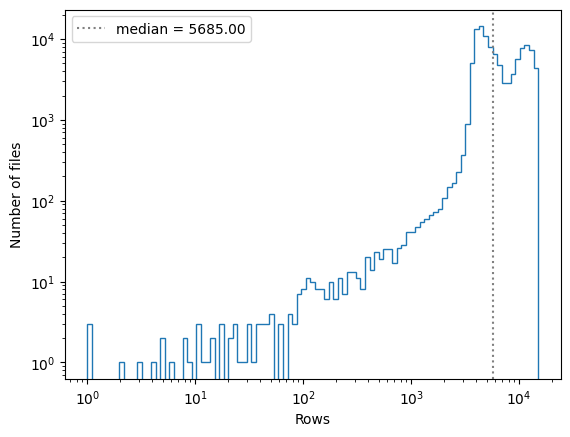

In [16]:
plot_size_hist(rows_df["num_rows"], "Rows")